<a href="https://colab.research.google.com/github/shailshree23/ML2_Lab/blob/main/FOIL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q networkx matplotlib seaborn pandas tabulate


In [3]:
import math
import itertools
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

In [4]:
# DOMAIN:
#
# Students:
#   Alice, Bob, Charlie, Diana
#
# Courses:
#   DBMS, OS, CN, AI, ML, SE
#
# Departments:
#   CSE, AIML
#
# Target:
#   TakesSameDeptCourse(Student, Course)
#
# Meaning:
#   A student takes a course if they are already enrolled in another
#   course from the same department.
# ---------------------------------------------------------------------------

CONSTANTS = [
    "Alice", "Bob", "Charlie", "Diana",
    "DBMS", "OS", "CN", "AI", "ML", "SE",
    "CSE", "AIML"
]

FACTS = {

    # Student -> Course
    "EnrolledIn": {
        ("Alice", "DBMS"),
        ("Alice", "OS"),

        ("Bob", "CN"),
        ("Bob", "DBMS"),

        ("Charlie", "AI"),
        ("Charlie", "ML"),

        ("Diana", "SE"),
        ("Diana", "OS")
    },

    # Course -> Department
    "OfferedBy": {
        ("DBMS", "CSE"),
        ("OS", "CSE"),
        ("CN", "CSE"),
        ("SE", "CSE"),

        ("AI", "AIML"),
        ("ML", "AIML")
    },

    # Course prerequisite -> Course
    "Prerequisite": {
        ("OS", "DBMS"),
        ("CN", "DBMS"),
        ("ML", "AI"),
        ("AI", "DBMS")
    },

    # Course type
    "CoreCourse": {
        ("DBMS",),
        ("OS",),
        ("CN",),
        ("AI",),
        ("ML",),
        ("SE",)
    }
}

ARITY = {
    "EnrolledIn": 2,
    "OfferedBy": 2,
    "Prerequisite": 2,
    "CoreCourse": 1
}

# Target relation
TARGET = "TakesSameDeptCourse"

TARGET_VARS = ("x", "y")

In [6]:
def is_true(pred, args):
    """Closed-world lookup."""
    return tuple(args) in FACTS[pred]


def ground_truth(x, y):
    """
    x takes a course y if:

    1. x is enrolled in some course z
    2. z is offered by department d
    3. y is also offered by department d

    Logical form:

    EnrolledIn(x,z),
    OfferedBy(z,d),
    OfferedBy(y,d)

    Therefore:

    TakesSameDeptCourse(x,y)
    """

    for z in CONSTANTS:

        enrolled = is_true(
            "EnrolledIn",
            (x, z)
        )

        if not enrolled:
            continue

        for d in CONSTANTS:

            same_department_1 = is_true(
                "OfferedBy",
                (z, d)
            )

            same_department_2 = is_true(
                "OfferedBy",
                (y, d)
            )

            if same_department_1 and same_department_2:
                return True

    return False


# ---------------------------------------------------------------------------
# Only student-course pairs are considered.
# This avoids meaningless combinations such as:
# TakesSameDeptCourse(DBMS, Alice)
# ---------------------------------------------------------------------------

STUDENTS = [
    "Alice",
    "Bob",
    "Charlie",
    "Diana"
]

COURSES = [
    "DBMS",
    "OS",
    "CN",
    "AI",
    "ML",
    "SE"
]

ALL_PAIRS = [
    (student, course)
    for student in STUDENTS
    for course in COURSES
]

POSITIVES = [
    p for p in ALL_PAIRS
    if ground_truth(*p)
]

NEGATIVES = [
    p for p in ALL_PAIRS
    if not ground_truth(*p)
]


print("=" * 78)
print(" FOIL : FIRST ORDER INDUCTIVE LEARNER ".center(78, "="))
print("=" * 78)

print("\nStudents:")
print(STUDENTS)

print("\nCourses:")
print(COURSES)

print("\nTotal possible student-course pairs:", len(ALL_PAIRS))

print("\nPositive examples:")
print(len(POSITIVES))
print(POSITIVES)

print("\nNegative examples:")
print(len(NEGATIVES))


# ---------------------------------------------------------------------------
# Display knowledge base
# ---------------------------------------------------------------------------

kb_rows = []

for p in FACTS:

    for t in sorted(FACTS[p]):

        kb_rows.append([
            p,
            ", ".join(t)
        ])


print("\nBACKGROUND KNOWLEDGE BASE")

print(
    tabulate(
        kb_rows,
        headers=["Predicate", "Arguments"],
        tablefmt="grid"
    )
)

==================== FOIL : FIRST ORDER INDUCTIVE LEARNER ====================

Students:
['Alice', 'Bob', 'Charlie', 'Diana']

Courses:
['DBMS', 'OS', 'CN', 'AI', 'ML', 'SE']

Total possible student-course pairs: 24

Positive examples:
14
[('Alice', 'DBMS'), ('Alice', 'OS'), ('Alice', 'CN'), ('Alice', 'SE'), ('Bob', 'DBMS'), ('Bob', 'OS'), ('Bob', 'CN'), ('Bob', 'SE'), ('Charlie', 'AI'), ('Charlie', 'ML'), ('Diana', 'DBMS'), ('Diana', 'OS'), ('Diana', 'CN'), ('Diana', 'SE')]

Negative examples:
10

BACKGROUND KNOWLEDGE BASE
+--------------+-------------+
| Predicate    | Arguments   |
+==============+=============+
| EnrolledIn   | Alice, DBMS |
+--------------+-------------+
| EnrolledIn   | Alice, OS   |
+--------------+-------------+
| EnrolledIn   | Bob, CN     |
+--------------+-------------+
| EnrolledIn   | Bob, DBMS   |
+--------------+-------------+
| EnrolledIn   | Charlie, AI |
+--------------+-------------+
| EnrolledIn   | Charlie, ML |
+--------------+-------------+
| En

In [7]:
# ============================================================================
# CELL 5 : LITERALS, BINDINGS AND RULE EVALUATION
# ============================================================================

def lit_str(lit):

    neg, pred, vs = lit

    return (
        ("not " if neg else "")
        + "%s(%s)" % (pred, ",".join(vs))
    )


def rule_str(body):

    head = "%s(%s)" % (
        TARGET,
        ",".join(TARGET_VARS)
    )

    if not body:
        return head + " :- "

    return (
        head
        + " :- "
        + ", ".join(lit_str(l) for l in body)
    )


def extend_bindings(bindings, lit):
    """
    Apply one literal to a binding table.

    Returns:
        new_bindings
        parents
    """

    neg, pred, vs = lit

    new_bindings = []
    parents = []

    for i, b in enumerate(bindings):

        if neg:

            args = tuple(
                b[v]
                for v in vs
            )

            if not is_true(pred, args):

                new_bindings.append(dict(b))
                parents.append(i)

        else:

            for fact in FACTS[pred]:

                nb = dict(b)

                ok = True

                for var, val in zip(vs, fact):

                    if var in nb:

                        if nb[var] != val:
                            ok = False
                            break

                    else:

                        nb[var] = val

                if ok:

                    new_bindings.append(nb)
                    parents.append(i)

    return new_bindings, parents


def evaluate_rule(body, pairs):
    """
    Which student-course pairs does this rule cover?
    """

    bindings = [
        {
            "x": a,
            "y": b
        }
        for (a, b) in pairs
    ]

    for lit in body:

        bindings, _ = extend_bindings(
            bindings,
            lit
        )

    return {
        (b["x"], b["y"])
        for b in bindings
    }


def split_bindings(bindings, pos_set):
    """
    Return positive and negative binding indices.
    """

    pos_idx = [
        i
        for i, b in enumerate(bindings)
        if (b["x"], b["y"]) in pos_set
    ]

    neg_idx = [
        i
        for i, b in enumerate(bindings)
        if (b["x"], b["y"]) not in pos_set
    ]

    return pos_idx, neg_idx

In [8]:
NEW_VAR_POOL = [
    "z",
    "d",
    "w",
    "v"
]

ENFORCE_LINKAGE = True
USE_NEGATION = False


def has_dangling_variable(body):

    counts = {}

    for _, _, vs in body:

        for v in vs:

            counts[v] = counts.get(v, 0) + 1

    return any(
        v not in TARGET_VARS and c < 2
        for v, c in counts.items()
    )


def candidate_literals(body):

    used = set(TARGET_VARS)

    for _, _, vs in body:
        used.update(vs)

    fresh = next(
        v
        for v in NEW_VAR_POOL
        if v not in used
    )

    allow_new = not (
        ENFORCE_LINKAGE
        and has_dangling_variable(body)
    )

    pool = sorted(used)

    if allow_new:
        pool.append(fresh)

    existing = set(used)

    cands = []

    for pred, k in ARITY.items():

        for combo in itertools.product(
            pool,
            repeat=k
        ):

            # Literal must connect to the existing rule
            if not any(
                v in existing
                for v in combo
            ):
                continue

            # Only one occurrence of fresh variable
            if combo.count(fresh) > 1:
                continue

            for neg in (
                (False, True)
                if USE_NEGATION
                else (False,)
            ):

                if neg and fresh in combo:
                    continue

                lit = (
                    neg,
                    pred,
                    combo
                )

                if lit not in body:
                    cands.append(lit)

    return cands


def n_new_vars(lit, body):

    used = set(TARGET_VARS)

    for _, _, vs in body:
        used.update(vs)

    return len([
        v
        for v in set(lit[2])
        if v not in used])

In [9]:
def foil_gain(p0, n0, p1, n1, t):

    if (
        p1 == 0
        or p0 == 0
        or t == 0
    ):

        return float("-inf")

    return t * (
        math.log2(
            p1 / (p1 + n1)
        )
        -
        math.log2(
            p0 / (p0 + n0)
        ))

In [10]:
TRACE = []

RULES = []

ROUND_LOG = []

In [11]:
def learn_one_rule(pos, neg, round_no):

    pos_set = set(pos)

    universe = list(pos) + list(neg)

    body = []

    bindings = [
        {
            "x": a,
            "y": b
        }
        for (a, b) in universe
    ]

    pos_idx, neg_idx = split_bindings(
        bindings,
        pos_set
    )

    p0 = len(pos_idx)
    n0 = len(neg_idx)

    step = 0

    while n0 > 0 and step < 6:

        step += 1

        scored = []

        candidates = candidate_literals(body)

        for lit in candidates:

            nb, parents = extend_bindings(
                bindings,
                lit
            )

            npos, nneg = split_bindings(
                nb,
                pos_set
            )

            p1 = len(npos)
            n1 = len(nneg)

            surviving_parents = {
                parents[i]
                for i in npos
            }

            t = len(
                surviving_parents
                & set(pos_idx)
            )

            g = foil_gain(
                p0,
                n0,
                p1,
                n1,
                t
            )

            scored.append(
                dict(
                    round=round_no,
                    step=step,
                    literal=lit_str(lit),
                    p1=p1,
                    n1=n1,
                    t=t,
                    gain=g,
                    newvars=n_new_vars(
                        lit,
                        body
                    )
                )
            )

        if not scored:
            break

        scored.sort(
            key=lambda d: (
                -d["gain"],
                d["newvars"],
                d["literal"]
            )
        )

        TRACE.extend(scored)

        best = scored[0]

        if best["gain"] == float("-inf"):
            break

        best_lit = next(
            l
            for l in candidates
            if lit_str(l) == best["literal"]
        )

        print(
            "\n  Step %d : rule before -> %s   (p=%d, n=%d)"
            % (
                step,
                rule_str(body),
                p0,
                n0
            )
        )

        valid_scores = [
            s
            for s in scored
            if s["gain"] > float("-inf")
        ]

        if valid_scores:

            top = pd.DataFrame(
                valid_scores
            )[
                [
                    "literal",
                    "p1",
                    "n1",
                    "t",
                    "gain"
                ]
            ].head(6)

            top["gain"] = top["gain"].round(3)

            print(
                tabulate(
                    top,
                    headers=[
                        "candidate literal",
                        "p1",
                        "n1",
                        "t",
                        "FOIL_Gain"
                    ],
                    tablefmt="simple",
                    showindex=False
                )
            )

        print(
            "  --> CHOSEN : %s"
            % best["literal"]
        )

        body.append(best_lit)

        bindings, _ = extend_bindings(
            bindings,
            best_lit
        )

        pos_idx, neg_idx = split_bindings(
            bindings,
            pos_set
        )

        p0 = len(pos_idx)
        n0 = len(neg_idx)

    return body, p0, n0

In [12]:
def foil(positives, negatives):

    remaining = list(positives)

    round_no = 0

    while remaining:

        round_no += 1

        print("\n" + "=" * 78)

        print(
            " OUTER LOOP ROUND %d : %d positive example(s) still uncovered"
            % (
                round_no,
                len(remaining)
            )
        )

        print("=" * 78)

        body, p_end, n_end = learn_one_rule(
            remaining,
            negatives,
            round_no
        )

        covered = (
            evaluate_rule(
                body,
                ALL_PAIRS
            )
            & set(remaining)
        )

        if not covered:

            print(
                "  ! rule covers nothing new - stopping"
            )

            break

        RULES.append(body)

        ROUND_LOG.append(
            dict(
                round=round_no,
                rule=rule_str(body),
                literals=len(body),
                covered=len(covered),
                remaining_before=len(remaining),
                final_p=p_end,
                final_n=n_end
            )
        )

        print(
            "\n  LEARNED RULE %d : %s"
            % (
                round_no,
                rule_str(body)
            )
        )

        print(
            "  Covers positives : %s"
            % sorted(covered)
        )

        remaining = [
            p
            for p in remaining
            if p not in covered
        ]

    return RULES

In [13]:
foil(
    POSITIVES,
    NEGATIVES
)

print("\n" + "=" * 78)
print(
    " FINAL LEARNED RULE SET ".center(78, "=")
)
print("=" * 78)

for i, r in enumerate(RULES, 1):

    print(
        "  R%d : %s"
        % (
            i,
            rule_str(r)
        )
    )


trace_df = pd.DataFrame(TRACE)

if not trace_df.empty:

    trace_df = trace_df[
        trace_df.gain > float("-inf")
    ].reset_index(drop=True)


 OUTER LOOP ROUND 1 : 14 positive example(s) still uncovered

  Step 1 : rule before -> TakesSameDeptCourse(x,y) :-    (p=14, n=10)
candidate literal      p1    n1    t    FOIL_Gain
-------------------  ----  ----  ---  -----------
EnrolledIn(x,y)         8     0    8        6.221
EnrolledIn(z,y)        20    12   14        1.393
Prerequisite(z,y)      10     6    4        0.398
CoreCourse(y)          14    10   14        0
EnrolledIn(x,z)        28    20   14        0
OfferedBy(y,z)         14    10   14        0
  --> CHOSEN : EnrolledIn(x,y)

  LEARNED RULE 1 : TakesSameDeptCourse(x,y) :- EnrolledIn(x,y)
  Covers positives : [('Alice', 'DBMS'), ('Alice', 'OS'), ('Bob', 'CN'), ('Bob', 'DBMS'), ('Charlie', 'AI'), ('Charlie', 'ML'), ('Diana', 'OS'), ('Diana', 'SE')]

 OUTER LOOP ROUND 2 : 6 positive example(s) still uncovered

  Step 1 : rule before -> TakesSameDeptCourse(x,y) :-    (p=6, n=10)
candidate literal      p1    n1    t    FOIL_Gain
-------------------  ----  ----  ---  ---

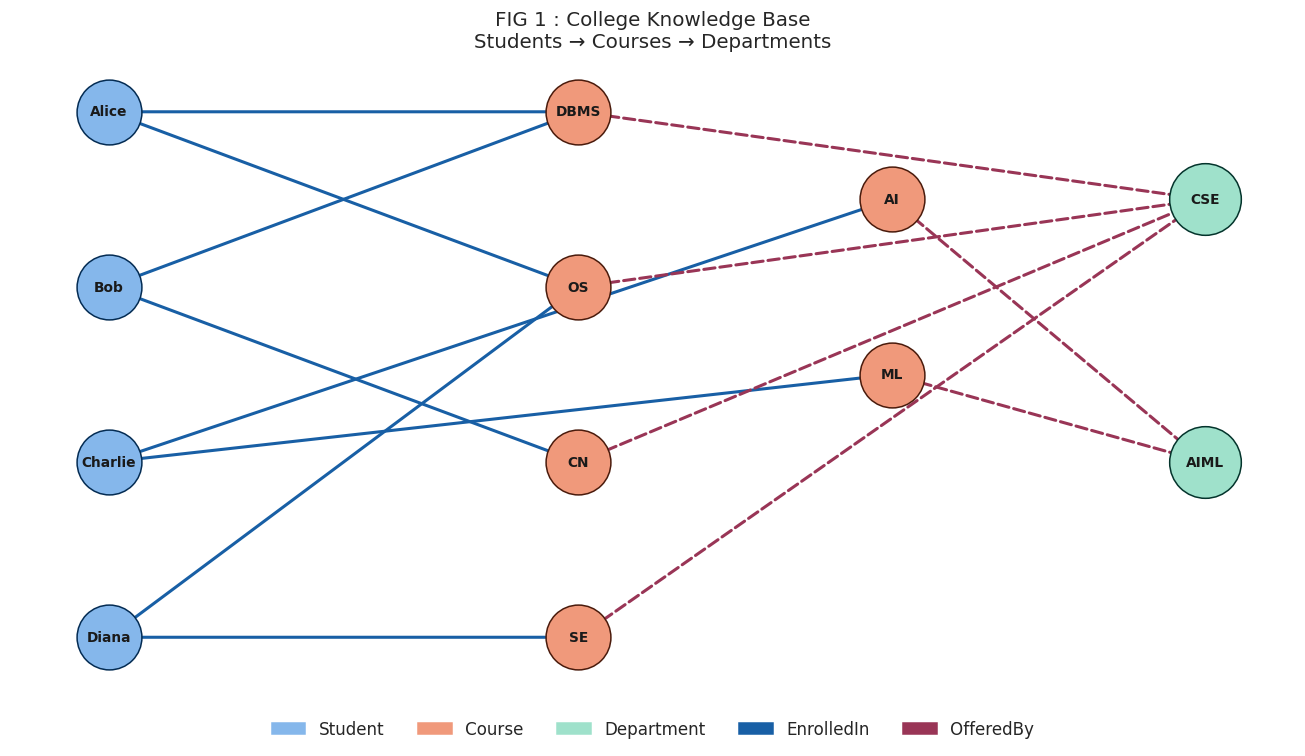

In [14]:
G = nx.DiGraph()

# Add students and courses
G.add_nodes_from(
    STUDENTS + COURSES
)

# Student -> Course edges
for a, b in FACTS["EnrolledIn"]:

    G.add_edge(
        a,
        b,
        rel="EnrolledIn"
    )

# Course -> Department edges
for a, b in FACTS["OfferedBy"]:

    G.add_edge(
        a,
        b,
        rel="OfferedBy"
    )


pos_layout = {

    "Alice": (-4, 3),
    "Bob": (-4, 1),
    "Charlie": (-4, -1),
    "Diana": (-4, -3),

    "DBMS": (-1, 3),
    "OS": (-1, 1),
    "CN": (-1, -1),
    "AI": (1, 2),
    "ML": (1, 0),
    "SE": (-1, -3),

    "CSE": (3, 2),
    "AIML": (3, -1)
}


fig, ax = plt.subplots(
    figsize=(12, 7)
)


student_nodes = STUDENTS

course_nodes = COURSES

department_nodes = [
    "CSE",
    "AIML"
]


nx.draw_networkx_nodes(
    G,
    pos_layout,
    nodelist=student_nodes,
    node_color="#85B7EB",
    node_size=1800,
    edgecolors="#042C53",
    ax=ax
)


nx.draw_networkx_nodes(
    G,
    pos_layout,
    nodelist=course_nodes,
    node_color="#F0997B",
    node_size=1800,
    edgecolors="#4A1B0C",
    ax=ax
)


nx.draw_networkx_nodes(
    G,
    pos_layout,
    nodelist=department_nodes,
    node_color="#9FE1CB",
    node_size=2200,
    edgecolors="#04342C",
    ax=ax
)


nx.draw_networkx_labels(
    G,
    pos_layout,
    font_size=9,
    font_weight="bold",
    ax=ax
)


enrolled_edges = [
    (a, b)
    for a, b, d in G.edges(data=True)
    if d["rel"] == "EnrolledIn"
]


department_edges = [
    (a, b)
    for a, b, d in G.edges(data=True)
    if d["rel"] == "OfferedBy"
]


nx.draw_networkx_edges(
    G,
    pos_layout,
    edgelist=enrolled_edges,
    edge_color="#185FA5",
    width=2,
    arrowsize=18,
    ax=ax
)


nx.draw_networkx_edges(
    G,
    pos_layout,
    edgelist=department_edges,
    edge_color="#993556",
    width=2,
    style="dashed",
    arrowsize=18,
    ax=ax
)


ax.legend(
    handles=[
        Patch(
            color="#85B7EB",
            label="Student"
        ),
        Patch(
            color="#F0997B",
            label="Course"
        ),
        Patch(
            color="#9FE1CB",
            label="Department"
        ),
        Patch(
            color="#185FA5",
            label="EnrolledIn"
        ),
        Patch(
            color="#993556",
            label="OfferedBy"
        )
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=5,
    frameon=False
)


ax.set_title(
    "FIG 1 : College Knowledge Base\n"
    "Students → Courses → Departments",
    fontsize=13
)

ax.axis("off")

plt.tight_layout()
plt.show()

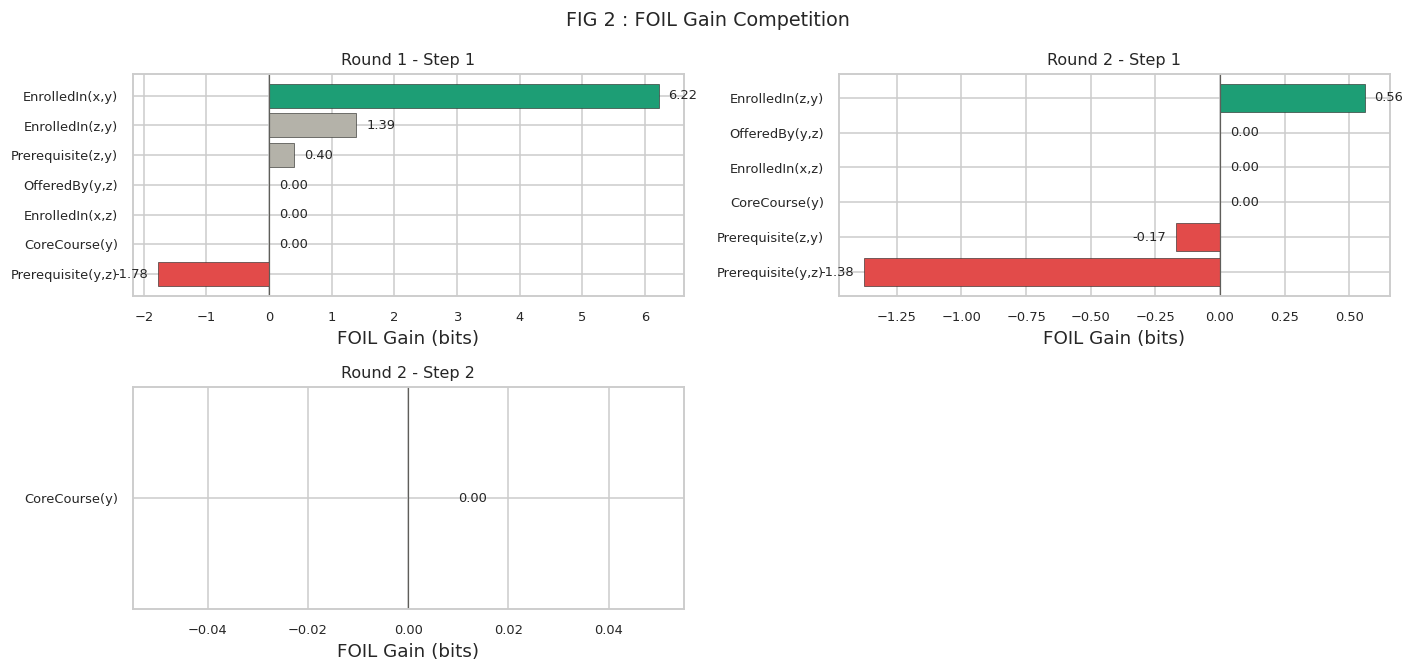

In [15]:
if not trace_df.empty:

    steps = (
        trace_df
        .groupby(["round", "step"])
        .size()
        .index
        .tolist()
    )

    ncol = 2

    nrow = int(
        math.ceil(
            len(steps) / ncol
        )
    )

    fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=(13, 3.1 * nrow)
    )

    axes = np.array(
        axes
    ).reshape(-1)


    for ax, (rnd, stp) in zip(
        axes,
        steps
    ):

        sub = trace_df[
            (trace_df["round"] == rnd)
            &
            (trace_df["step"] == stp)
        ]

        sub = sub.sort_values(
            "gain",
            ascending=True
        ).tail(7)

        hi = sub["gain"].max()

        lo = min(
            0.0,
            sub["gain"].min()
        )

        span = max(
            hi - lo,
            0.5
        )

        colors = [
            "#1D9E75"
            if g == hi
            else (
                "#E24B4A"
                if g < 0
                else "#B4B2A9"
            )
            for g in sub["gain"]
        ]

        ax.barh(
            sub["literal"],
            sub["gain"],
            color=colors,
            edgecolor="#2C2C2A",
            lw=0.4
        )

        for yi, g in enumerate(
            sub["gain"]
        ):

            off = 0.02 * span

            ax.text(
                g + off
                if g >= 0
                else g - off,
                yi,
                "%.2f" % g,
                va="center",
                ha="left"
                if g >= 0
                else "right",
                fontsize=8.5
            )

        ax.axvline(
            0,
            color="#5F5E5A",
            lw=0.8
        )

        ax.set_title(
            "Round %d - Step %d"
            % (rnd, stp),
            fontsize=10.5
        )

        ax.set_xlabel(
            "FOIL Gain (bits)"
        )

        ax.tick_params(
            labelsize=8.5
        )


    for ax in axes[len(steps):]:
        ax.axis("off")


    fig.suptitle(
        "FIG 2 : FOIL Gain Competition",
        fontsize=12.5
    )

    plt.tight_layout()
    plt.show()

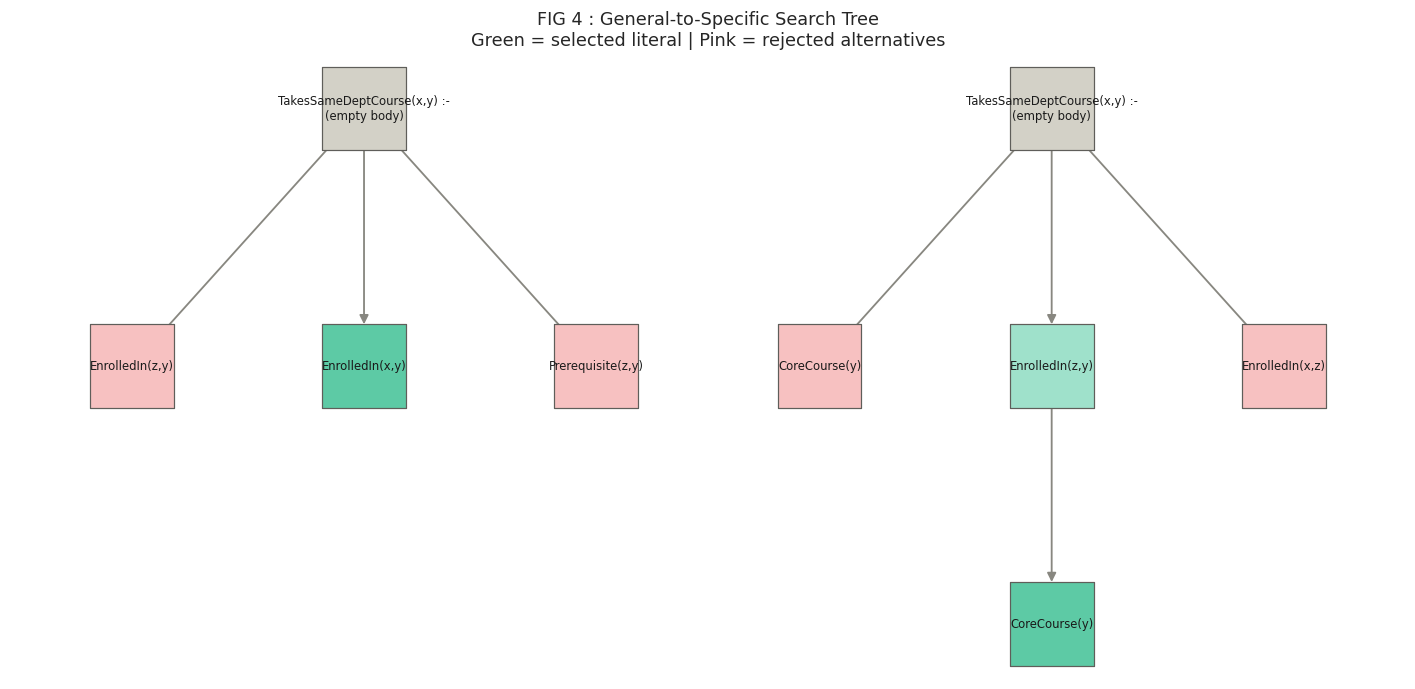

In [16]:
T = nx.DiGraph()

labels = {}
colors = {}
tpos = {}

y_gap = 1.0


for r_i, body in enumerate(
    RULES,
    1
):

    x_base = (
        r_i - 1
    ) * 4.0

    root = (
        "R%d_s0"
        % r_i
    )

    T.add_node(root)

    labels[root] = (
        "%s(x,y) :-\n"
        "(empty body)"
        % TARGET
    )

    colors[root] = "#D3D1C7"

    tpos[root] = (
        x_base,
        0
    )

    prev = root


    for s_i, lit in enumerate(
        body,
        1
    ):

        sibs = trace_df[
            (trace_df["round"] == r_i)
            &
            (trace_df["step"] == s_i)
        ]

        sibs = sibs.sort_values(
            "gain",
            ascending=False
        ).head(3)

        losers = [
            s
            for s in sibs["literal"]
            if s != lit_str(lit)
        ][:2]


        for j, lname in enumerate(
            losers
        ):

            nid = (
                "R%d_s%d_x%d"
                % (
                    r_i,
                    s_i,
                    j
                )
            )

            T.add_node(nid)

            T.add_edge(
                prev,
                nid
            )

            labels[nid] = lname

            colors[nid] = "#F7C1C1"

            tpos[nid] = (
                x_base - 1.35 + j * 2.7,
                -s_i * y_gap
            )


        nid = (
            "R%d_s%d"
            % (
                r_i,
                s_i
            )
        )

        T.add_node(nid)

        T.add_edge(
            prev,
            nid
        )

        labels[nid] = lit_str(lit)

        colors[nid] = "#9FE1CB"

        tpos[nid] = (
            x_base,
            -s_i * y_gap
        )

        prev = nid

    colors[prev] = "#5DCAA5"


fig, ax = plt.subplots(
    figsize=(13, 6.4)
)


nx.draw_networkx_edges(
    T,
    tpos,
    edge_color="#888780",
    width=1.2,
    arrows=True,
    arrowsize=12,
    node_size=3000,
    ax=ax
)


nx.draw_networkx_nodes(
    T,
    tpos,
    node_color=[
        colors[n]
        for n in T.nodes()
    ],
    node_size=3000,
    node_shape="s",
    edgecolors="#5F5E5A",
    linewidths=0.8,
    ax=ax
)


nx.draw_networkx_labels(
    T,
    tpos,
    labels=labels,
    font_size=7.6,
    ax=ax
)


ax.set_title(
    "FIG 4 : General-to-Specific Search Tree\n"
    "Green = selected literal | Pink = rejected alternatives",
    fontsize=11.5
)

ax.axis("off")

plt.tight_layout()
plt.show()

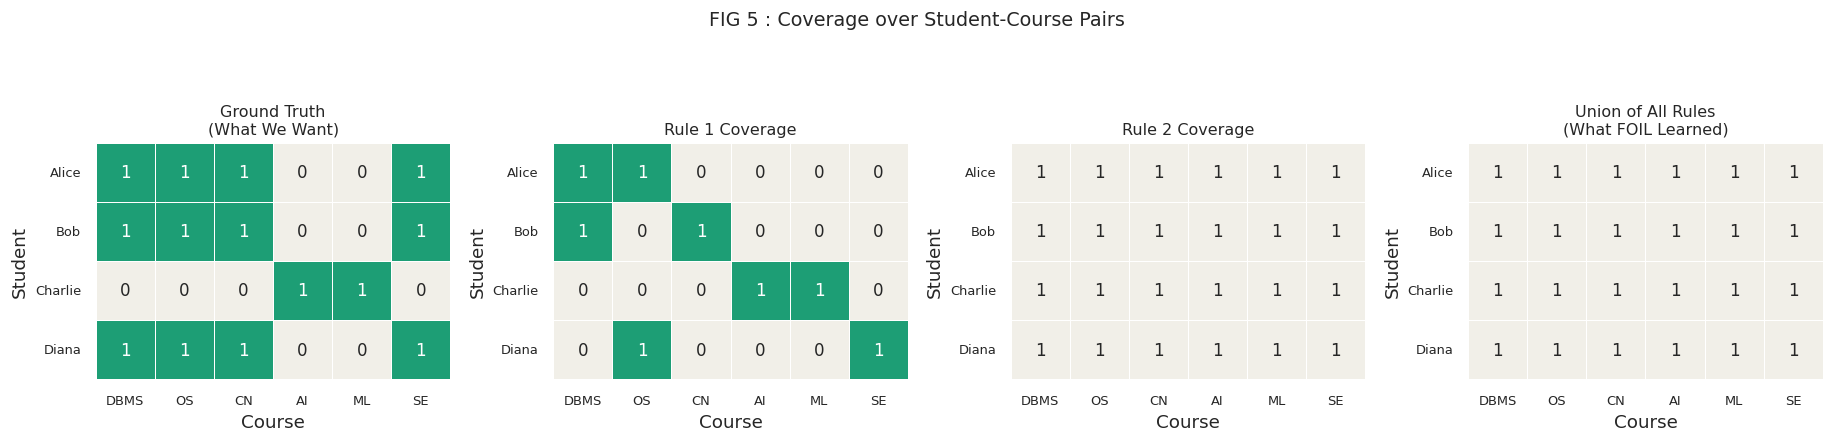

In [17]:
n_students = len(STUDENTS)

n_courses = len(COURSES)


truth = np.array([
    [
        1
        if ground_truth(student, course)
        else 0
        for course in COURSES
    ]
    for student in STUDENTS
])


cov_maps = [
    truth
]

titles = [
    "Ground Truth\n(What We Want)"
]


union = np.zeros_like(
    truth
)


for i, body in enumerate(
    RULES,
    1
):

    cov = evaluate_rule(
        body,
        ALL_PAIRS
    )

    m = np.array([
        [
            1
            if (student, course) in cov
            else 0
            for course in COURSES
        ]
        for student in STUDENTS
    ])

    union = np.maximum(
        union,
        m
    )

    cov_maps.append(m)

    titles.append(
        "Rule %d Coverage"
        % i
    )


cov_maps.append(union)

titles.append(
    "Union of All Rules\n(What FOIL Learned)"
)


fig, axes = plt.subplots(
    1,
    len(cov_maps),
    figsize=(
        4.2 * len(cov_maps),
        4.4
    )
)


for ax, m, t in zip(
    axes,
    cov_maps,
    titles
):

    sns.heatmap(
        m,
        annot=True,
        fmt="d",
        cbar=False,
        square=True,
        cmap=sns.color_palette(
            ["#F1EFE8", "#1D9E75"]
        ),
        linewidths=0.6,
        linecolor="white",
        xticklabels=COURSES,
        yticklabels=STUDENTS,
        ax=ax
    )

    ax.set_title(
        t,
        fontsize=10.5
    )

    ax.set_xlabel(
        "Course"
    )

    ax.set_ylabel(
        "Student"
    )

    ax.tick_params(
        labelsize=8.5
    )


fig.suptitle(
    "FIG 5 : Coverage over Student-Course Pairs",
    fontsize=12.5
)

plt.tight_layout()
plt.show()

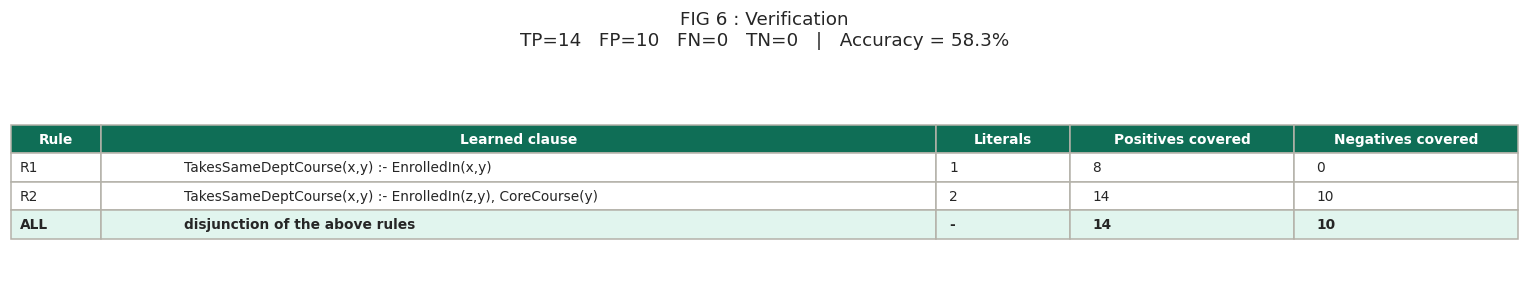

In [18]:
predicted = set()


for body in RULES:

    predicted |= evaluate_rule(
        body,
        ALL_PAIRS
    )


TP = len([
    p
    for p in ALL_PAIRS
    if p in predicted
    and ground_truth(*p)
])


FP = len([
    p
    for p in ALL_PAIRS
    if p in predicted
    and not ground_truth(*p)
])


FN = len([
    p
    for p in ALL_PAIRS
    if p not in predicted
    and ground_truth(*p)
])


TN = (
    len(ALL_PAIRS)
    - TP
    - FP
    - FN
)


rows = []


for i, body in enumerate(
    RULES,
    1
):

    cov = evaluate_rule(
        body,
        ALL_PAIRS
    )

    rows.append([
        "R%d" % i,
        rule_str(body),
        len(body),
        len(
            cov & set(POSITIVES)
        ),
        len(
            cov & set(NEGATIVES)
        )
    ])


rows.append([
    "ALL",
    "disjunction of the above rules",
    "-",
    TP,
    FP
])


fig, ax = plt.subplots(
    figsize=(
        14,
        1.05 + 0.62 * len(rows)
    )
)


ax.axis("off")


tbl = ax.table(
    cellText=rows,
    colLabels=[
        "Rule",
        "Learned clause",
        "Literals",
        "Positives covered",
        "Negatives covered"
    ],
    cellLoc="left",
    loc="center",
    colWidths=[
        0.06,
        0.56,
        0.09,
        0.15,
        0.15
    ]
)


tbl.auto_set_font_size(False)

tbl.set_fontsize(9)

tbl.scale(
    1,
    1.7
)


for (r, c), cell in tbl.get_celld().items():

    cell.set_edgecolor(
        "#B4B2A9"
    )

    if r == 0:

        cell.set_facecolor(
            "#0F6E56"
        )

        cell.set_text_props(
            color="white",
            weight="bold"
        )

    elif r == len(rows):

        cell.set_facecolor(
            "#E1F5EE"
        )

        cell.set_text_props(
            weight="bold"
        )


accuracy = (
    100.0
    * (TP + TN)
    / len(ALL_PAIRS)
)


ax.set_title(
    "FIG 6 : Verification\n"
    "TP=%d   FP=%d   FN=%d   TN=%d   |   Accuracy = %.1f%%"
    % (
        TP,
        FP,
        FN,
        TN,
        accuracy
    ),
    fontsize=12,
    pad=16
)


plt.tight_layout()

plt.show()

In [19]:
print("\n" + "=" * 78)

print(
    " ROUND-BY-ROUND SUMMARY ".center(
        78,
        "="
    )
)

print("=" * 78)


if ROUND_LOG:

    print(
        tabulate(
            pd.DataFrame(ROUND_LOG),
            headers="keys",
            tablefmt="grid",
            showindex=False
        )
    )


print(
    "\nCONFUSION MATRIX over %d student-course pairs"
    % len(ALL_PAIRS)
)


print(
    tabulate(
        [
            [
                "Actual POSITIVE",
                TP,
                FN
            ],
            [
                "Actual NEGATIVE",
                FP,
                TN
            ]
        ],
        headers=[
            "",
            "Predicted POS",
            "Predicted NEG"
        ],
        tablefmt="grid"
    )
)


print("\nTALKING POINTS")

print(
    "1. EnrolledIn(x,z) connects a student to an intermediate course."
)

print(
    "2. OfferedBy(z,d) introduces an intermediate department variable."
)

print(
    "3. OfferedBy(y,d) connects the target course to the same department."
)

print(
    "4. FOIL learns relationships involving variables that do not appear "
    "in the target head."
)

print(
    "5. FOIL counts BINDINGS rather than simply counting examples."
)

print(
    "6. FOIL_Gain determines which candidate literal should be added."
)

print(
    "7. Sequential covering allows FOIL to learn multiple rules."
)

print(
    "8. The learned rule can be interpreted as:"
)

print(
    "   TakesSameDeptCourse(x,y) :- "
    "EnrolledIn(x,z), OfferedBy(z,d), OfferedBy(y,d)"
)

print("=" * 78)


=========================== ROUND-BY-ROUND SUMMARY ===========================
+---------+------------------------------------------------------------+------------+-----------+--------------------+-----------+-----------+
|   round | rule                                                       |   literals |   covered |   remaining_before |   final_p |   final_n |
+=========+============================================================+============+===========+====================+===========+===========+
|       1 | TakesSameDeptCourse(x,y) :- EnrolledIn(x,y)                |          1 |         8 |                 14 |         8 |         0 |
+---------+------------------------------------------------------------+------------+-----------+--------------------+-----------+-----------+
|       2 | TakesSameDeptCourse(x,y) :- EnrolledIn(z,y), CoreCourse(y) |          2 |         6 |                  6 |         8 |        12 |
+---------+---------------------------------------------------